<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/02_Quantum_Optimal_Transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Global Fubini-Study Distance

The global state is a pure vector in $\mathcal{H}_{SE}$, whose projective space is $\mathbb{C}P^{d_S d_E - 1}.$

The global state of a multibody system can be written as when focusing on a subsystem $S_a$. Consider two nearby pure states
$|\Psi_{SE}(t)\rangle$ and $|\Psi_{SE}'(t)\rangle$.

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{d_S}\sum_{i=1}^{d_E}
\psi_{k i}(t)\,
|s_k^{(a)}\rangle|e_i^{(\neq a)}\rangle.
$$

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{d_S}\sum_{j=1}^{d_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$
Their separation is quantified by the Fubini–Study distance
\begin{equation}
d_{FS}(|\Psi\rangle,|\Phi\rangle)
=
\arccos\!\left(|\langle\Psi|\Phi\rangle|\right).
\end{equation}
Under unitary evolution,
\begin{eqnarray}
\langle\Psi_{SE}(t)|\Psi_{SE}'(t)\rangle
&=&
\langle\Psi_{SE}(0)|U^\dagger U|\Psi_{SE}'(0)\rangle \nonumber\\
&=&
\langle\Psi_{SE}(0)|\Psi_{SE}'(0)\rangle,
\end{eqnarray}
so that
\begin{equation}
d_{FS}\!\left(|\Psi_{SE}(t)\rangle,|\Psi_{SE}'(t)\rangle\right)
=
d_{FS}\!\left(|\Psi_{SE}(0)\rangle,|\Psi_{SE}'(0)\rangle\right).
\end{equation}

## 2. Local Reduced Density Matrix Distance - Bures Distance
The reduced state of the subsystem is obtained by tracing out the environment:

$$
\rho_{S_a} =
\sum_{i=1}^{d_E}\lambda_i^E
|\chi_i^{S_a}\rangle\langle \chi_i^{S_a}|.
$$

$$
\rho_{S'_a} =
\sum_{j=1}^{d_E}\lambda_j^E
|\chi_j^{S'_a}\rangle\langle \chi_j^{S'_a}|.
$$
Distance between reduced states of $|\Psi_{SE}\rangle$ and $|\Psi_{SE}'\rangle$ which are $\rho^{S_a}$ and $\rho^{S_a'}$ respectively.
$$d_B
=\sqrt{2-2\sqrt{F(\rho^{S_a},\rho^{S_a'})}}.
$$


## 3. Local Reduced Geometric Quantum State Distance - Quantum Wassertein Distance
<summary><strong>Geometric Quantum State Representation</strong></summary>

Rather than viewing the reduced state solely as a density matrix, we adopt the **geometric quantum state (GQS)** representation.

Each conditional pure state defines a point in projective Hilbert space,

$$
|\chi_i^{S_a}\rangle →
\mathbf{Z}_i^{S_a}(t)
=\big[c_1^{(i)}(t):\cdots:c_d^{(i)}(t)\big]
\in\mathbb{C}P^{d_E-1}.
$$

The reduced state is represented as a probability measure,

$$
Q^{S_a}(Z,t)
=\sum_{i=1}^{d_E}\lambda_i^{E}(t)\,
\delta\!\left(Z-\mathbf{Z}_i^{S_a}(t)\right).
$$

$$
Q^{S'_a}(Z,t)
=\sum_{j=1}^{d_E}\lambda_j^{E}(t)\,
\delta\!\left(Z-\mathbf{Z}_j^{S'_a}(t)\right).
$$

This representation retains the **geometric structure** of mixed quantum states.


$$
W_p(Q^{S_a},Q^{S_a'})
=
\left(
\inf_{\pi\in\Pi(Q^{S_a},Q^{S_a'})}
\sum_{i,j}\pi_{ij}\,
d_{FS}(\mathbf{Z}_i^{S_a},\mathbf{Z}_j^{S_a'})^p
\right)^{1/p}.
$$

Unlike operator-based metrics, Wasserstein distance captures **geometric transport and deformation** of quantum-state ensembles.


In [1]:
!rm -rf Qaos
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")




Module ready to go :)


In [2]:

from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site, random_wavefunction, print_density_matrix, print_gqs_single_site, print_wavefunction
from gqs.plotsCompare import plot_density_matrices_and_gqs_distances
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance


### 1. Global Fubini-Study Distance - 3 Qubit System

In [3]:
dhilbert = 2
nchain = 3
psi1 = random_wavefunction(nchain)
print("Global State - 1")
print_wavefunction(psi1)
psi2 = random_wavefunction(nchain)
print("Global State - 2")
print_wavefunction(psi2)
print("\n \n Fubini-Study Distance between them: ",Psi_Dist(psi1,psi2))


Global State - 1
(0.0095+0.0399j) |000>       + (0.4141+0.0265j) |001>       + (0.0094-0.1074j) |010>       + (0.0845-0.3393j) |011>       +
(-0.3367+0.5130j) |100>      + (-0.2256+0.0841j) |101>      + (-0.1906-0.0182j) |110>      + (0.3568+0.3062j) |111>      
Global State - 2
(-0.4895-0.1477j) |000>      + (-0.2889-0.0946j) |001>      + (-0.1257+0.2083j) |010>      + (-0.3174+0.1376j) |011>      +
(-0.2981+0.4349j) |100>      + (0.1392+0.1367j) |101>       + (-0.2036+0.1632j) |110>      + (-0.2822-0.0602j) |111>     

 
 Fubini-Study Distance between them:  1.443201027089351


### 2. Local Distance - Wasserstein Distance between GQSs and Bures Distance between reduced density matrix - 3 Qubit System

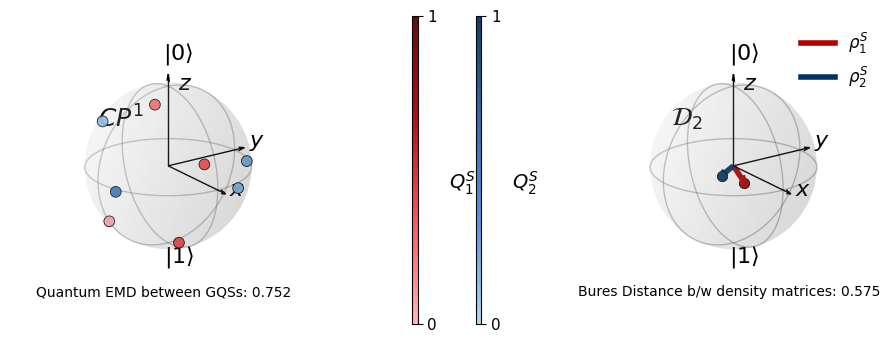

In [4]:
system_site = 0
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)

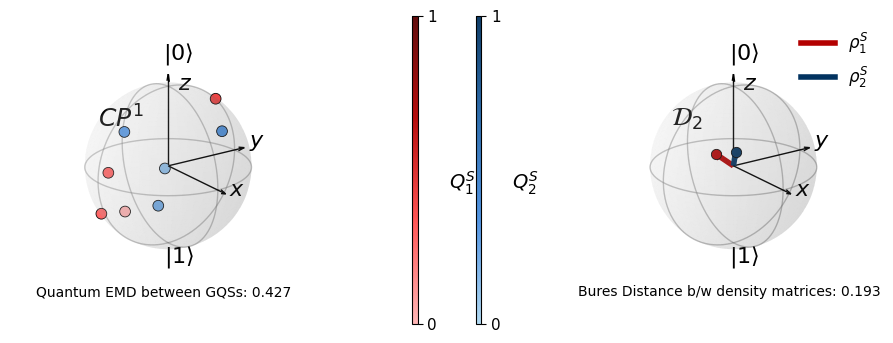

In [5]:
system_site = 1
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)

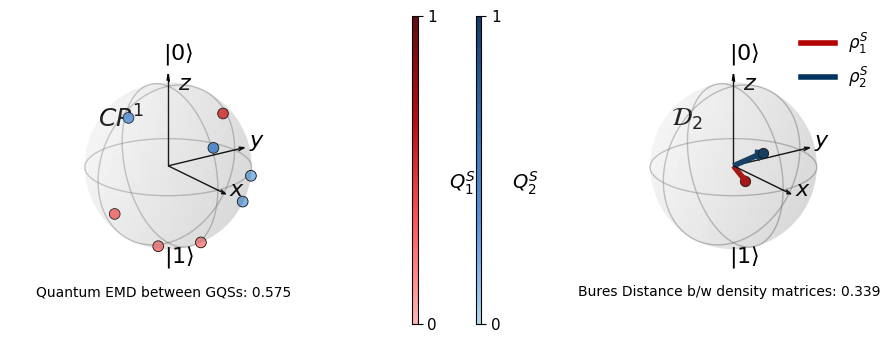

In [6]:
system_site = 2
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)

### 1. Global Fubini-Study Distance - 4 Qubit System

In [7]:
dhilbert = 2
nchain = 4
psi1 = random_wavefunction(nchain)
print("Global State - 1")
print_wavefunction(psi1)
psi2 = random_wavefunction(nchain)
print("Global State - 2")
print_wavefunction(psi2)
print("\n \n Fubini-Study Distance between them: ",Psi_Dist(psi1,psi2))

Global State - 1
(-0.1792+0.0413j) |0000>     + (-0.0763-0.1597j) |0001>     + (-0.2586-0.0373j) |0010>     + (0.0862+0.1291j) |0011>      +
(-0.1343-0.3550j) |0100>     + (-0.0897+0.3939j) |0101>     + (-0.1404+0.2189j) |0110>     + (-0.1055+0.0418j) |0111>     +
(-0.0038-0.2349j) |1000>     + (-0.0385-0.2623j) |1001>     + (0.0938-0.1897j) |1010>      + (-0.2554-0.0048j) |1011>     +
(-0.1105-0.1100j) |1100>     + (0.1609-0.1092j) |1101>      + (0.1971-0.0046j) |1110>      + (0.0085-0.3437j) |1111>     
Global State - 2
(0.0249+0.2132j) |0000>      + (-0.0893+0.0425j) |0001>     + (-0.4349+0.0841j) |0010>     + (0.0768+0.1375j) |0011>      +
(-0.0990-0.0666j) |0100>     + (-0.2230-0.3571j) |0101>     + (-0.1753+0.0091j) |0110>     + (0.1602-0.1544j) |0111>      +
(-0.0284-0.3785j) |1000>     + (0.1130-0.0122j) |1001>      + (0.1229+0.2517j) |1010>      + (-0.1403-0.1121j) |1011>     +
(-0.0143-0.3567j) |1100>     + (-0.0054-0.0137j) |1101>     + (0.1214+0.0258j) |1110>      + (-0.064

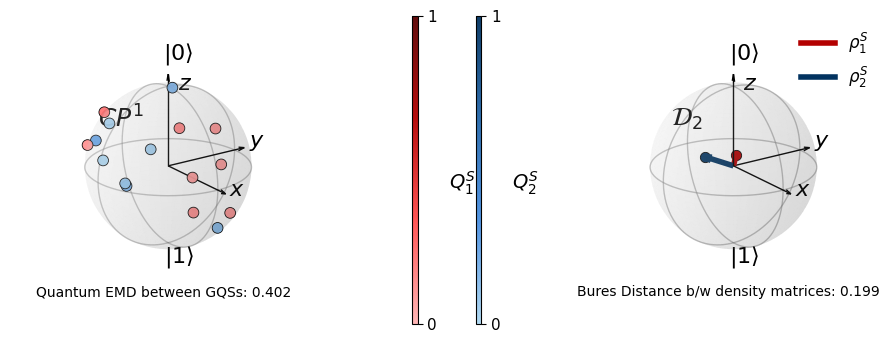

In [8]:
system_site = 0
# ________Reduced density matrices of the two Global States____________
rho1_s = rho_single_spin(dhilbert, nchain, system_site, psi1)
rho2_s = rho_single_spin(dhilbert, nchain, system_site, psi2)
Dr0 = bures_distance(rho1_s, rho2_s)
# ________Reduced Geometric quantum state at site-a____________
chi1_s,q1_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi1)
chi2_s,q2_s = Reduced_state_single_site(dhilbert,nchain,system_site,Psi_SE=psi2)
#________Wasserstein Distances between the two____________
Dl0 = Quantum_EMD(chi1_s,q1_s,chi2_s,q2_s)
_=plot_density_matrices_and_gqs_distances(states1=chi1_s, weights1=q1_s,states2=chi2_s,weights2=q2_s,
                                        Dist_rho = Dr0,Dist_GQS = Dl0)